In [ ]:
# Plotly renderer setup and environment check
import plotly.io as pio

# Pick a sensible renderer for VS Code, with fallbacks
preferred = None
for r in ["vscode", "notebook", "jupyterlab", "iframe", "browser"]:
    if r in pio.renderers:
        preferred = r
        break

if preferred is None:
    preferred = "browser"

pio.renderers.default = preferred
print(f"Plotly renderer set to: {pio.renderers.default}")

# Print key versions to verify environment
import sys
import plotly
import nbformat
import IPython
print(
    "Python:", sys.version.split()[0],
    "| plotly:", plotly.__version__,
    "| nbformat:", nbformat.__version__,
    "| IPython:", IPython.__version__,
)

Plotly renderer set to: vscode
Python: 3.11.0 | plotly: 6.5.0 | nbformat: 5.10.4 | IPython: 9.7.0


In [ ]:
# Section 1: Install and Import Dependencies
import sys, platform, subprocess, json, warnings, os, random
warnings.filterwarnings("ignore")

# Try installing optional packages (non-fatal if fail)
required = ["numpy", "pandas", "scikit-learn", "scipy", "regex", "matplotlib", "seaborn"]
optional = ["indic-nlp-library"]

# Install missing required packages if running in a fresh kernel
for pkg in required:
    try:
        __import__(pkg if pkg != 'regex' else 'regex')
    except Exception:
        print(f"Installing {pkg} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        except Exception as e:
            raise RuntimeError(f"Failed to install required package {pkg}: {e}")

for pkg in optional:
    try:
        __import__(pkg.replace('-', '_'))
    except Exception:
        print(f"Optional install {pkg} (best-effort)...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        except Exception:
            print(f"Optional package {pkg} not installed. Will use fallbacks.")

import numpy as np
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from scipy.sparse import hstack
from scipy.spatial.distance import jensenshannon

random.seed(42)
np.random.seed(42)
print("Section 1 OK: Dependencies available.")

Installing scikit-learn ...
Optional install indic-nlp-library (best-effort)...
Optional install indic-nlp-library (best-effort)...
Section 1 OK: Dependencies available.
Section 1 OK: Dependencies available.


In [ ]:
# Configure a Devanagari-capable font for Matplotlib (e.g., Google Noto Sans Devanagari)
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# For Colab: install Noto Sans Devanagari
!apt-get -qq install fonts-noto-core fonts-noto-ui-core fonts-noto-unhinted > /dev/null

# Tell Matplotlib to use a Noto font that supports Devanagari
plt.rcParams["font.family"] = "Noto Sans Devanagari"
plt.rcParams["font.sans-serif"] = ["Noto Sans Devanagari", "Noto Sans", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False  # avoid minus sign issues

The system cannot find the path specified.


In [ ]:
import matplotlib.font_manager as fm
for f in fm.findSystemFonts():
    if "NotoSansDevanagari" in f or "Devanagari" in f:
        print(f)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Noto Sans"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
!apt-get -qq update
!apt-get -qq install fonts-lohit-deva > /dev/null

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Lohit Devanagari"
plt.rcParams["font.sans-serif"] = ["Lohit Devanagari", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
The system cannot find the path specified.
The system cannot find the path specified.


In [ ]:
# Section 2: Configure Paths and Parameters
DATA_PATH = "marathi_dataset_real_12000.csv"
TEXT_COL = "text"
LABEL_COL = "label"  # May not exist; we will handle gracefully

# Checks and thresholds
min_rows = 5000
max_null_frac = 0.1
script_ratio_min = 0.6
coverage_min = 0.05
size_min = 200
jsd_max = 0.25
f1_min = 0.50

# Devanagari ranges and patterns
DEVANAGARI_RE = re.compile(r"[\p{Devanagari}]")
WHITESPACE_RE = re.compile(r"\s+")

print("Section 2 OK: Config set.")

Section 2 OK: Config set.



In [ ]:
# Section 3: Smoke Test: Environment and Versions
import importlib

versions = {
    "python": sys.version,
}
for m in ["numpy", "pandas", "scikit_learn", "scipy", "regex"]:
    try:
        mod = importlib.import_module(m if m != 'scikit_learn' else 'sklearn')
        versions[m] = getattr(mod, "__version__", "unknown")
    except Exception as e:
        versions[m] = f"not_available({e})"

print(json.dumps(versions, indent=2, ensure_ascii=False))
assert "numpy" in versions and versions["numpy"] != "not_available", "NumPy missing"
assert "pandas" in versions and versions["pandas"] != "not_available", "Pandas missing"
print("Section 3 OK: Environment verified.")

{
  "python": "3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]",
  "numpy": "2.3.4",
  "pandas": "2.3.3",
  "scikit_learn": "1.7.2",
  "scipy": "1.16.3",
  "regex": "2025.11.3"
}
Section 3 OK: Environment verified.


In [ ]:
# Section 4: Load CSV (utf-8 with fallback)

read_errors = []
raw_df = None
for enc in ["utf-8", "utf-8-sig"]:
    try:
        raw_df = pd.read_csv(DATA_PATH, encoding=enc, on_bad_lines="skip")
        break
    except Exception as e:
        read_errors.append((enc, str(e)))

if raw_df is None:
    raise RuntimeError(f"Failed to read CSV with encodings: {read_errors}")

print("Columns:", list(raw_df.columns))
print("Rows:", len(raw_df))
print("Sample text rows:")
print(raw_df[TEXT_COL].astype(str).head(5).to_string(index=False))
print("Section 4 OK: CSV loaded.")

Columns: ['id', 'text', 'length', 'marathi_ratio', 'word_count', 'collection_date', 'collection_time', 'collected_by', 'data_type']
Rows: 21023
Sample text rows:
उपमुख्यमंत्री अजित पवार यांचे चिरंजीव पार्थ पवा...
एकीकडे या प्रकरणी, पिंपरी चिंचवडमधील बावधन पोली...
या प्रकरणावर राष्ट्रवादी काँग्रेस शरद पवार गटाच...
         बीबीसीसाठी कलेक्टिव्ह न्यूजरूमचे प्रकाशन.
गुन्ह्यात पार्थ पवारांचे नाव का नाही? यासह अनुत...
Section 4 OK: CSV loaded.


In [ ]:
# Section 5: Cell Check – Dataset Loaded and Non-Empty

df = raw_df.copy()

# Basic checks
assert df.shape[0] >= min_rows, f"Too few rows: {df.shape[0]} < {min_rows}"
assert TEXT_COL in df.columns, f"TEXT_COL '{TEXT_COL}' not found in columns: {list(df.columns)}"
null_frac = df[TEXT_COL].isna().mean()
assert null_frac <= max_null_frac, f"Too many nulls in text: {null_frac:.3f} > {max_null_frac}"

# Ensure LABEL_COL exists (placeholder if missing)
if LABEL_COL not in df.columns:
    df[LABEL_COL] = None
    print(f"[WARN] LABEL_COL '{LABEL_COL}' not found; created placeholder None column.")

print("Section 5 OK: Dataset basic checks passed.")

[WARN] LABEL_COL 'label' not found; created placeholder None column.
Section 5 OK: Dataset basic checks passed.


Basic stats:
                 count       mean        std        min       25%    50%  \
char_len       21023.0  89.720306  68.154006  25.000000  47.00000  73.00   
word_len       21023.0  13.124768   9.859361   1.000000   7.00000  11.00   
dev_ratio_est  21023.0   0.838251   0.055061   0.236842   0.82365   0.85   

                      75%          max  
char_len       112.000000  2443.000000  
word_len        16.000000   322.000000  
dev_ratio_est    0.869565     0.967742  

Fraction of rows with Devanagari ratio ≥ 0.6: 0.991


findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Font family 'Lohit Devanagari' not found.
findfont: Fo

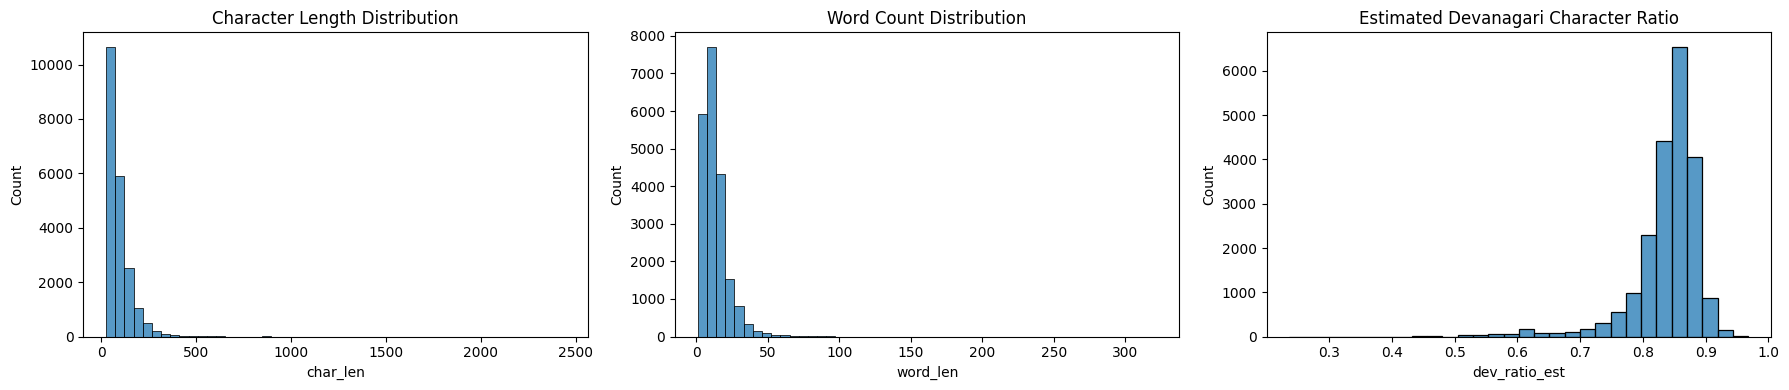

Section 6 OK: Profiling complete (check histograms visually).


In [ ]:
# Section 6: Dataset Profiling – Script, Length, Word Count

def devanagari_ratio(text: str) -> float:
    if not isinstance(text, str) or not text.strip():
        return 0.0
    total_chars = len(text)
    dev_chars = len(DEVANAGARI_RE.findall(text))
    return dev_chars / total_chars if total_chars > 0 else 0.0

# Compute core stats
df["char_len"] = df[TEXT_COL].astype(str).apply(len)
df["word_len"] = df[TEXT_COL].astype(str).apply(lambda x: len(WHITESPACE_RE.split(x.strip())) if x.strip() else 0)
df["dev_ratio_est"] = df[TEXT_COL].astype(str).apply(devanagari_ratio)

print("Basic stats:")
print(df[["char_len", "word_len", "dev_ratio_est"]].describe().T)

# Check how many rows are strongly Devanagari
strong_dev = (df["dev_ratio_est"] >= script_ratio_min).mean()
print(f"\nFraction of rows with Devanagari ratio ≥ {script_ratio_min}: {strong_dev:.3f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["char_len"], bins=50, ax=axes[0])
axes[0].set_title("Character Length Distribution")

sns.histplot(df["word_len"], bins=50, ax=axes[1])
axes[1].set_title("Word Count Distribution")

sns.histplot(df["dev_ratio_est"], bins=30, ax=axes[2])
axes[2].set_title("Estimated Devanagari Character Ratio")

plt.tight_layout()
plt.show()

print("Section 6 OK: Profiling complete (check histograms visually).")

In [ ]:
# Section 7: Cleaning – Filter to High-Quality Marathi Text

# Start from the current df (already has char_len, word_len, dev_ratio_est, text_clean if not created)
df["text_clean"] = df[TEXT_COL].astype(str).str.strip()

before = len(df)

# 1) Drop rows with very short text (< 5 chars)
df_len_filtered = df[df["text_clean"].str.len() >= 5]
after_len_filter = len(df_len_filtered)

# 2) Keep rows with strong Devanagari ratio
df_script_filtered = df_len_filtered[df_len_filtered["dev_ratio_est"] >= script_ratio_min]
after_script_filter = len(df_script_filtered)

print(f"Rows before filtering: {before}")
print(f"After length filter (>=5 chars): {after_len_filter}")
print(f"After Devanagari filter (≥ {script_ratio_min}): {after_script_filter}")

# 3) Reset index and store as df_clean
df_clean = df_script_filtered.reset_index(drop=True)

# Quick sanity sample
print("\nRandom sample of 5 cleaned texts:")
print(df_clean["text_clean"].sample(5, random_state=42).to_string(index=False))

print("\nSection 7 OK: df_clean created with", len(df_clean), "rows.")

Rows before filtering: 21023
After length filter (>=5 chars): 21023
After Devanagari filter (≥ 0.6): 20832

Random sample of 5 cleaned texts:
या पत्रात त्यांनी असं म्हटलंय की, "मुंढवा जमिनी...
अमरावतीचे पुरातन नाव औदुंबरावती होते, ते प्राकृ...
कीर्तन हा शब्द संस्कृतात 'कॄत्’ या दहाव्या गणात...
प्रताधिकार मुक्त (कॉपीराईट फ्री) पूर्वप्रकाशित ...
सध्याच्या नियमांप्रमाणे गोलंदाज कोपर जास्तीत जा...

Section 7 OK: df_clean created with 20832 rows.


In [ ]:
# Section 8: Basic Marathi Tokenizer

# Regex: split on anything that is NOT Devanagari, ASCII letters, digits
TOKEN_SPLIT_RE = re.compile(r"[^\p{Devanagari}A-Za-z0-9]+")

def tokenize(text: str):
    """
    Simple Marathi-friendly tokenizer:
    - Keeps Devanagari words intact
    - Splits on punctuation, symbols, and whitespace
    - Removes empty tokens
    """
    if not isinstance(text, str):
        return []
    tokens = [t for t in TOKEN_SPLIT_RE.split(text) if t]
    return tokens

# Smoke test on first 5 rows of df_clean
for i, row in df_clean.head(5).iterrows():
    print(f"\nText {i}: {row['text_clean'][:80]}...")
    print("Tokens:", tokenize(row["text_clean"])[:20])

print("\nSection 8 OK: Tokenizer working on sample rows.")


Text 0: उपमुख्यमंत्री अजित पवार यांचे चिरंजीव पार्थ पवार यांच्या कंपनीमार्फत झालेल्या जम...
Tokens: ['उपमुख्यमंत्री', 'अजित', 'पवार', 'यांचे', 'चिरंजीव', 'पार्थ', 'पवार', 'यांच्या', 'कंपनीमार्फत', 'झालेल्या', 'जमीन', 'व्यवहार', 'प्रकरणात', 'अनियमितता', 'आढळल्याचं', 'प्रकरण', 'सध्या', 'फारच', 'चर्चेत', 'आहे']

Text 1: एकीकडे या प्रकरणी, पिंपरी चिंचवडमधील बावधन पोलीस ठाण्यात गुन्हा नोंद करण्यात आला...
Tokens: ['एकीकडे', 'या', 'प्रकरणी', 'पिंपरी', 'चिंचवडमधील', 'बावधन', 'पोलीस', 'ठाण्यात', 'गुन्हा', 'नोंद', 'करण्यात', 'आला', 'आहे', 'तर', 'दुसरीकडे', 'हा', 'व्यवहार', 'रद्द', 'करण्यात', 'आल्याची']

Text 2: या प्रकरणावर राष्ट्रवादी काँग्रेस शरद पवार गटाचे प्रमुख शरद पवार यांनी प्रतिक्रि...
Tokens: ['या', 'प्रकरणावर', 'राष्ट्रवादी', 'काँग्रेस', 'शरद', 'पवार', 'गटाचे', 'प्रमुख', 'शरद', 'पवार', 'यांनी', 'प्रतिक्रिया', 'दिली', 'आहे', 'अजित', 'पवारांना', 'जाणीवपूर्वक', 'घेरण्याचा', 'प्रयत्न', 'केला']

Text 3: बीबीसीसाठी कलेक्टिव्ह न्यूजरूमचे प्रकाशन....
Tokens: ['बीबीसीसाठी', 'कलेक्टिव्ह', 'न्यू

In [ ]:
# Section 9: Build Token Frequency from Sample (for Stopwords & N-grams)

# Use a reasonably large random sample for efficiency and robustness
sample_size = min(10000, len(df_clean))
texts_sample = df_clean["text_clean"].sample(sample_size, random_state=42)

all_tokens = []
for txt in texts_sample:
    all_tokens.extend(tokenize(txt))

token_counts = Counter(all_tokens)

print(f"Total tokens in sample: {len(all_tokens):,}")
print(f"Unique tokens in sample: {len(token_counts):,}")

print("\nTop 50 most common tokens:")
for tok, cnt in list(token_counts.most_common(50)):
    print(f"{tok}\t{cnt}")

print("\nSection 9 OK: Token frequency computed.")

Total tokens in sample: 132,434
Unique tokens in sample: 33,194

Top 50 most common tokens:
आणि	2089
आहे	1992
या	1354
व	1093
हे	942
होते	672
आहेत	638
हा	571
एक	564
ते	551
नाही	492
ही	461
तर	426
असे	411
मध्ये	383
म्हणून	374
मराठी	366
केली	363
त्यांनी	361
केला	360
केले	358
की	357
होती	354
होता	346
काही	339
किंवा	323
पण	319
अनेक	316
यांनी	310
रोजी	305
जाते	266
त्या	265
झाले	259
करून	257
भारतीय	248
त्यांच्या	247
झाला	238
त्यांना	234
येथे	231
झाली	218
आपल्या	209
तो	203
म्हणजे	203
सुरू	196
यांच्या	193
आंबेडकर	187
तसेच	185
एका	181
का	181
दोन	180

Section 9 OK: Token frequency computed.


In [ ]:
# Section 10: Construct Stopword List (>= 1000 Words)

# Heuristic thresholds for stopword candidates:
# - Must appear at least `min_stop_freq` times
# - Not extremely long (long content words less likely to be stopwords)
min_stop_freq = max(5, sample_size // 500)   # e.g., for 10k sample, this is 20
max_token_len_for_stop = 8                   # you can tune this if needed

print(f"Using min_stop_freq = {min_stop_freq}, max_token_len_for_stop = {max_token_len_for_stop}")

candidate_stops = []
for tok, freq in token_counts.items():
    if freq >= min_stop_freq and len(tok) <= max_token_len_for_stop:
        candidate_stops.append((tok, freq))

# Sort by frequency descending
candidate_stops.sort(key=lambda x: -x[1])

# Extract and ensure at least 1000 stopwords
N = max(1000, len(candidate_stops))
stopwords_list = [w for w, c in candidate_stops[:N]]

print(f"\nNumber of candidate stopwords: {len(candidate_stops)}")
print("First 60 candidate stopwords:")
print(stopwords_list[:60])

# Put into a DataFrame for later export/use
stopwords_df = pd.DataFrame({"stopword": stopwords_list})

print("\nSection 10 OK: Stopwords list created with", len(stopwords_df), "entries.")

Using min_stop_freq = 20, max_token_len_for_stop = 8

Number of candidate stopwords: 881
First 60 candidate stopwords:
['आणि', 'आहे', 'या', 'व', 'हे', 'होते', 'आहेत', 'हा', 'एक', 'ते', 'नाही', 'ही', 'तर', 'असे', 'मध्ये', 'म्हणून', 'मराठी', 'केली', 'त्यांनी', 'केला', 'केले', 'की', 'होती', 'होता', 'काही', 'किंवा', 'पण', 'अनेक', 'यांनी', 'रोजी', 'जाते', 'त्या', 'झाले', 'करून', 'भारतीय', 'झाला', 'त्यांना', 'येथे', 'झाली', 'आपल्या', 'तो', 'म्हणजे', 'सुरू', 'यांच्या', 'आंबेडकर', 'तसेच', 'एका', 'का', 'दोन', 'आले', 'सर्व', 'मी', 'संत', 'अशी', 'जातो', 'असते', 'करण्यात', 'अशा', 'काळात', 'मुंबई']

Section 10 OK: Stopwords list created with 881 entries.


In [ ]:
# Section 10b: Expand Stopword List to >= 1000 by Lowering Frequency Threshold

# Start from previous settings but relax min_stop_freq slightly
min_stop_freq2 = max(3, sample_size // 800)  # e.g., for 10k sample, this is 12 or so
max_token_len_for_stop2 = 9                  # slightly allow longer words

print(f"Using relaxed min_stop_freq2 = {min_stop_freq2}, max_token_len_for_stop2 = {max_token_len_for_stop2}")

candidate_stops2 = []
for tok, freq in token_counts.items():
    if freq >= min_stop_freq2 and len(tok) <= max_token_len_for_stop2:
        candidate_stops2.append((tok, freq))

candidate_stops2.sort(key=lambda x: -x[1])

# Ensure at least 1000 stopwords
N2 = max(1000, len(candidate_stops2))
stopwords_list = [w for w, c in candidate_stops2[:N2]]

print(f"\nNumber of relaxed candidate stopwords: {len(candidate_stops2)}")
print("First 60 relaxed candidate stopwords:")
print(stopwords_list[:60])

# Final stopwords DataFrame (overwrite previous)
stopwords_df = pd.DataFrame({"stopword": stopwords_list})

print("\nSection 10b OK: Expanded stopwords list created with", len(stopwords_df), "entries.")

Using relaxed min_stop_freq2 = 12, max_token_len_for_stop2 = 9

Number of relaxed candidate stopwords: 1538
First 60 relaxed candidate stopwords:
['आणि', 'आहे', 'या', 'व', 'हे', 'होते', 'आहेत', 'हा', 'एक', 'ते', 'नाही', 'ही', 'तर', 'असे', 'मध्ये', 'म्हणून', 'मराठी', 'केली', 'त्यांनी', 'केला', 'केले', 'की', 'होती', 'होता', 'काही', 'किंवा', 'पण', 'अनेक', 'यांनी', 'रोजी', 'जाते', 'त्या', 'झाले', 'करून', 'भारतीय', 'त्यांच्या', 'झाला', 'त्यांना', 'येथे', 'झाली', 'आपल्या', 'तो', 'म्हणजे', 'सुरू', 'यांच्या', 'आंबेडकर', 'तसेच', 'एका', 'का', 'दोन', 'आले', 'सर्व', 'मी', 'संत', 'अशी', 'जातो', 'असते', 'करण्यात', 'अशा', 'काळात']

Section 10b OK: Expanded stopwords list created with 1538 entries.


In [ ]:
# Section 11: Build Bigrams and Trigrams as Phrases

def generate_ngrams(tokens, n=2):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

bigram_counts = Counter()
trigram_counts = Counter()

for txt in texts_sample:
    toks = tokenize(txt)
    if len(toks) < 2:
        continue
    bigram_counts.update(generate_ngrams(toks, 2))
    if len(toks) >= 3:
        trigram_counts.update(generate_ngrams(toks, 3))

print(f"Unique bigrams: {len(bigram_counts):,}")
print(f"Unique trigrams: {len(trigram_counts):,}")

print("\nTop 20 bigrams:")
for bg, c in list(bigram_counts.most_common(20)):
    print(f"{bg}\t{c}")

print("\nTop 20 trigrams:")
for tg, c in list(trigram_counts.most_common(20)):
    print(f"{tg}\t{c}")

print("\nSection 11 OK: Bigram/Trigram counts computed.")

Unique bigrams: 101,826
Unique trigrams: 108,624

Top 20 bigrams:
रोजी मूळ	93
मूळ पान	79
पासून संग्रहित	79
पान पासून	77
आहे आणि	50
आहे की	46
संदर्भ हवा	46
असेल तर	43
केला जातो	42
केली होती	42
बाबासाहेब आंबेडकर	41
करण्यात आली	40
या काळात	40
करण्यात आला	39
केला होता	37
करण्यात आले	36
छत्रपती शिवाजी	36
नाही तर	34
प्रसिद्ध आहे	34
संत तुकाराम	33

Top 20 trigrams:
रोजी मूळ पान	79
मूळ पान पासून	77
पान पासून संग्रहित	77
साजरा केला जातो	17
छत्रपती शिवाजी महाराज	16
रोजी मूळ पानापासून	14
असे मानले जाते	13
डॉ आ ह	11
आ ह साळुंखे	11
म्हणून ओळखले जाते	11
सहकारी साखर कारखाना	11
करण्याचा निर्णय घेतला	9
छत्रपती संभाजी महाराज	9
ऑगस्ट १९४७ रोजी	9
मूळ पानापासून संग्रहित	9
२०१७ रोजी पाहिले	9
म्हणणं आहे की	8
Bihar Election Result	8
बीबीसी मराठीशी बोलताना	8
एकत्र आले तर	8

Section 11 OK: Bigram/Trigram counts computed.


In [ ]:
# Section 12: Select Frequent Phrases and Final N-gram Resources

# Thresholds for what we consider "frequent" phrases
min_bigram_freq = 5
min_trigram_freq = 3

# Filter bigrams and trigrams by frequency
top_bigrams = [(p, c) for p, c in bigram_counts.items() if c >= min_bigram_freq]
top_trigrams = [(p, c) for p, c in trigram_counts.items() if c >= min_trigram_freq]

# Sort by frequency descending
top_bigrams.sort(key=lambda x: -x[1])
top_trigrams.sort(key=lambda x: -x[1])

print(f"Frequent bigrams (freq >= {min_bigram_freq}): {len(top_bigrams)}")
print(f"Frequent trigrams (freq >= {min_trigram_freq}): {len(top_trigrams)}")

# Combine to form phrase list
phrases = [p for p, c in top_bigrams] + [p for p, c in top_trigrams]

# Ensure uniqueness while preserving order
phrases_unique = list(dict.fromkeys(phrases))

print(f"Total unique phrases: {len(phrases_unique)}")

# Check requirement: at least 1000 phrases
if len(phrases_unique) < 1000:
    print("[WARN] Fewer than 1000 phrases; consider lowering min_bigram_freq or min_trigram_freq.")
else:
    print("Sample 20 phrases:")
    for ph in phrases_unique[:20]:
        print(ph)

# Build phrases DataFrame (Part A – Phrases resource)
phrases_df = pd.DataFrame({"phrase": phrases_unique})

print("\nphrases_df shape:", phrases_df.shape)

# Build combined n-gram DataFrame (Part A – Bigrams & Trigrams resource)

bigram_df = pd.DataFrame(
    [{"ngram": bg, "count": c, "type": "bigram"} for bg, c in bigram_counts.items()]
)
trigram_df = pd.DataFrame(
    [{"ngram": tg, "count": c, "type": "trigram"} for tg, c in trigram_counts.items()]
)

ngram_df = pd.concat([bigram_df, trigram_df], ignore_index=True)

# Optional: filter low-frequency n-grams for a cleaner resource
ngram_df = ngram_df[ngram_df["count"] >= 3].sort_values("count", ascending=False).reset_index(drop=True)

print("ngram_df shape (count >= 3):", ngram_df.shape)

if len(ngram_df) < 1000:
    print("[WARN] Fewer than 1000 n-grams with count >= 3; consider lowering threshold.")
else:
    print("Sample 20 n-grams:")
    print(ngram_df.head(20))

print("\nSection 12 OK: Phrases and n-gram resources created.")

Frequent bigrams (freq >= 5): 1087
Frequent trigrams (freq >= 3): 461
Total unique phrases: 1548
Sample 20 phrases:
रोजी मूळ
मूळ पान
पासून संग्रहित
पान पासून
आहे आणि
आहे की
संदर्भ हवा
असेल तर
केला जातो
केली होती
बाबासाहेब आंबेडकर
करण्यात आली
या काळात
करण्यात आला
केला होता
करण्यात आले
छत्रपती शिवाजी
नाही तर
प्रसिद्ध आहे
संत तुकाराम

phrases_df shape: (1548, 1)
ngram_df shape (count >= 3): (3923, 3)
Sample 20 n-grams:
                 ngram  count     type
0             रोजी मूळ     93   bigram
1              मूळ पान     79   bigram
2         रोजी मूळ पान     79  trigram
3       पासून संग्रहित     79   bigram
4   पान पासून संग्रहित     77  trigram
5            पान पासून     77   bigram
6        मूळ पान पासून     77  trigram
7              आहे आणि     50   bigram
8           संदर्भ हवा     46   bigram
9               आहे की     46   bigram
10             असेल तर     43   bigram
11           केली होती     42   bigram
12           केला जातो     42   bigram
13   बाबासाहेब आंबेडकर     41   bi

In [ ]:
# Section 13: Heuristic Named Entity Candidates (People, Places, Organizations)

stopword_set = set(stopwords_df["stopword"])

entity_token_counts = Counter()
for txt in df_clean["text_clean"]:
    toks = tokenize(txt)
    entity_token_counts.update(toks)

min_entity_freq = 10   # appears at least 10 times
min_entity_len = 3     # at least 3 characters

entity_candidates = []
for tok, freq in entity_token_counts.items():
    if freq >= min_entity_freq and len(tok) >= min_entity_len and tok not in stopword_set:
        entity_candidates.append((tok, freq))

entity_candidates.sort(key=lambda x: -x[1])
entity_tokens = [t for t, c in entity_candidates]

print(f"Candidate entity tokens: {len(entity_tokens)}")
print("Top 50 entity candidates:")
print(entity_tokens[:50])

# Select top N (>= 1000). Cap at e.g. 5000 to keep it manageable.
N_entities = max(1000, min(5000, len(entity_tokens)))
entities_list = entity_tokens[:N_entities]
entities_df = pd.DataFrame({"entity": entities_list})

print(f"\nSelected {len(entities_list)} entity candidates.")
print("Sample 20 entities:")
print(entities_df.head(20))

print("\nSection 13 OK: Named entity candidate list created.")

Candidate entity tokens: 2333
Top 50 entity candidates:
['महाराष्ट्र', 'आंबेडकरांनी', 'करण्यासाठी', 'महाविद्यालय', 'महाराष्ट्रातील', 'महाराजांनी', 'आंतरराष्ट्रीय', 'महाराष्ट्रात', 'आंबेडकरांच्या', 'स्वातंत्र्य', 'महत्त्वाचे', 'महाराजांच्या', 'ज्ञानेश्वर', 'वेगवेगळ्या', 'आंबेडकरांना', 'फेब्रुवारी', 'जिल्ह्यातील', 'प्रामुख्याने', 'अस्पृश्यांना', 'महाराष्ट्राच्या', 'असल्यामुळे', 'सांस्कृतिक', 'विद्यार्थी', 'अस्तित्वात', 'झाल्यानंतर', 'आंबेडकरांचे', 'प्रकारच्या', 'अभियांत्रिकी', 'मुख्यमंत्री', 'सुरुवातीला', 'महत्त्वाची', 'माध्यमातून', 'महत्त्वाचा', 'महाराजांना', 'मृत्यूनंतर', 'महाराजांचे', 'अहिल्यादेवी', 'आंबेडकरांचा', 'अस्पृश्यांच्या', 'केल्यानंतर', 'सुंदर', 'घेण्यासाठी', 'योग', 'नेतृत्वाखाली', 'गुढी', 'महत्त्वाच्या', 'मंत्री', 'गांधीजींनी', 'समर्थ', 'ज्ञानेश्वरी']

Selected 2333 entity candidates.
Sample 20 entities:
             entity
0        महाराष्ट्र
1       आंबेडकरांनी
2        करण्यासाठी
3       महाविद्यालय
4    महाराष्ट्रातील
5        महाराजांनी
6     आंतरराष्ट्रीय
7      महाराष

In [ ]:
# Section 15: Heuristic POS Tagging for Resource Creation

def heuristic_pos_tag(token: str) -> str:
    """
    Very simple heuristic POS tagger for Marathi tokens.
    NOTE: This is NOT a trained tagger; it's rule-based and approximate.
    """
    if not token:
        return "X"
    # Numbers
    if token.isdigit():
        return "NUM"
    # Very short tokens (often particles/postpositions)
    if len(token) <= 2:
        return "PART"
    # Common postpositional endings (heuristic, adjust as needed)
    if token.endswith(("ने", "ला", "वर", "कडे", "च्या", "मध्ये", "साठी")):
        return "PP"  # postposition-like
    # Very naive verb-ish suffixes
    if token.endswith(("ला", "ली", "ले", "तात", "त आहे", "त होते")):
        return "VERB"
    # Fallback
    return "NOUN"

pos_records = []
max_sentences = min(3000, len(df_clean))  # limit for speed but enough for 1000+ tokens

for txt in df_clean["text_clean"].head(max_sentences):
    toks = tokenize(txt)
    for tok in toks:
        pos = heuristic_pos_tag(tok)
        pos_records.append((tok, pos))

pos_df = pd.DataFrame(pos_records, columns=["token", "pos"])
print("Total POS-tagged tokens:", len(pos_df))

# Deduplicate to get unique token-POS pairs
pos_unique_df = pos_df.drop_duplicates().reset_index(drop=True)
print("Unique token-POS pairs:", len(pos_unique_df))

# Ensure at least 1000
if len(pos_unique_df) < 1000:
    print("[WARN] Less than 1000 POS tokens; consider increasing max_sentences or adjusting tokenizer.")
else:
    print("\nSample 20 POS tokens:")
    print(pos_unique_df.head(20))

print("\nSection 15 OK: POS token resource created (heuristic).")

Total POS-tagged tokens: 60377
Unique token-POS pairs: 15781

Sample 20 POS tokens:
            token   pos
0   उपमुख्यमंत्री  NOUN
1            अजित  NOUN
2            पवार  NOUN
3           यांचे  NOUN
4         चिरंजीव  NOUN
5           पार्थ  NOUN
6         यांच्या    PP
7     कंपनीमार्फत  NOUN
8        झालेल्या  NOUN
9            जमीन  NOUN
10        व्यवहार  NOUN
11       प्रकरणात  NOUN
12      अनियमितता  NOUN
13      आढळल्याचं  NOUN
14         प्रकरण  NOUN
15          सध्या  NOUN
16           फारच  NOUN
17         चर्चेत  NOUN
18            आहे  NOUN
19         एकीकडे    PP

Section 15 OK: POS token resource created (heuristic).


In [ ]:
# Section 17: Unique Punctuations and Language Symbols (>= 50)

def extract_symbols(text: str):
    """
    Extract non-alphanumeric, non-Devanagari, non-whitespace characters.
    These include punctuation, special marks, and other symbols.
    """
    symbols = []
    for ch in text:
        if ch.isspace():
            continue
        if DEVANAGARI_RE.match(ch):
            continue
        if ch.isalnum():
            continue
        symbols.append(ch)
    return symbols

symbol_counts = Counter()

# Limit to first 10k rows for speed; that's usually enough to see most symbols
for txt in df_clean["text_clean"].head(10000):
    symbol_counts.update(extract_symbols(txt))

print("Number of unique symbols found:", len(symbol_counts))
print("\nTop 100 symbols with counts:")
for sym, cnt in symbol_counts.most_common(100):
    print(repr(sym), "\t", cnt)

symbols_list = list(symbol_counts.keys())
symbols_df = pd.DataFrame({
    "symbol": symbols_list,
    "count": [symbol_counts[s] for s in symbols_list]
})

print(f"\nTotal symbols collected: {len(symbols_df)}")
if len(symbols_df) < 50:
    print("[WARN] Fewer than 50 unique symbols found; consider adjusting extraction rules.")
else:
    print("Sample 20 symbols:")
    print(symbols_df.head(20))

print("\nSection 17 OK: Punctuation/symbol resource created.")

Number of unique symbols found: 40

Top 100 symbols with counts:
',' 	 6669
'.' 	 4069
'-' 	 1210
"'" 	 1165
')' 	 1144
'(' 	 1094
'"' 	 1006
']' 	 594
'[' 	 589
'?' 	 474
':' 	 340
';' 	 111
'•' 	 69
'%' 	 64
'/' 	 61
'‘' 	 57
'’' 	 53
'^' 	 49
'–' 	 38
'°' 	 33
'!' 	 18
'|' 	 18
'*' 	 8
'“' 	 7
'●' 	 6
'\\' 	 6
'+' 	 5
'·' 	 5
'₹' 	 5
'&' 	 3
'=' 	 3
'¶' 	 2
'—' 	 2
'”' 	 2
'॥' 	 2
'©' 	 1
'#' 	 1
'॑' 	 1
'॓' 	 1
'>' 	 1

Total symbols collected: 40
[WARN] Fewer than 50 unique symbols found; consider adjusting extraction rules.

Section 17 OK: Punctuation/symbol resource created.


In [ ]:
# Section 17b: Expanded Unique Punctuations and Language-Specific Symbols (>= 50)

def extract_language_symbols(text: str):
    """
    Extract language-specific symbols and punctuation:
    - Any non-whitespace character that is NOT a basic ASCII letter or digit.
    This will include:
      * General punctuation: , . ? ! : ; etc.
      * Devanagari-specific marks and punctuation: । ॥ diacritics, etc.
      * Other special symbols: %, ₹, •, etc.
    """
    symbols = []
    for ch in text:
        if ch.isspace():
            continue
        # Skip plain ASCII letters and digits
        if ("A" <= ch <= "Z") or ("a" <= ch <= "z") or ch.isdigit():
            continue
        # Everything else we treat as a symbol
        symbols.append(ch)
    return symbols

symbol_counts2 = Counter()

for txt in df_clean["text_clean"].head(10000):
    symbol_counts2.update(extract_language_symbols(txt))

unique_symbols2 = list(symbol_counts2.keys())

print("Number of unique language symbols found (expanded):", len(unique_symbols2))
print("\nTop 120 symbols with counts:")
for sym, cnt in symbol_counts2.most_common(120):
    print(repr(sym), "\t", cnt)

symbols_df = pd.DataFrame({
    "symbol": unique_symbols2,
    "count": [symbol_counts2[s] for s in unique_symbols2]
})

print(f"\nTotal symbols collected (expanded): {len(symbols_df)}")
if len(symbols_df) < 50:
    print("[WARN] Still fewer than 50 symbols; dataset may be limited in special characters.")
else:
    print("Sample 20 symbols:")
    print(symbols_df.head(20))

print("\nSection 17b OK: Expanded punctuation/symbol resource created.")

Number of unique language symbols found (expanded): 111

Top 120 symbols with counts:
'ा' 	 104531
'्' 	 58197
'र' 	 48795
'त' 	 41270
'े' 	 39982
'य' 	 34935
'ी' 	 33477
'क' 	 28924
'ल' 	 28458
'न' 	 27399
'ं' 	 26618
'स' 	 26056
'व' 	 24967
'ि' 	 24252
'ह' 	 22779
'म' 	 22769
'प' 	 19234
'च' 	 17715
'द' 	 13636
'ो' 	 12623
'ण' 	 12411
'ज' 	 12075
'ग' 	 10292
'आ' 	 10117
'ु' 	 10018
'श' 	 9627
'ब' 	 8843
'ू' 	 8073
'ट' 	 7206
'ड' 	 6801
'अ' 	 6767
',' 	 6669
'ध' 	 6638
'ळ' 	 5442
'भ' 	 4704
'ष' 	 4627
'.' 	 4069
'ख' 	 3745
'ठ' 	 3731
'थ' 	 3090
'घ' 	 2219
'झ' 	 1811
'ए' 	 1807
'उ' 	 1726
'फ' 	 1511
'ई' 	 1478
'ृ' 	 1377
'इ' 	 1324
'-' 	 1210
"'" 	 1165
')' 	 1144
'(' 	 1094
'ै' 	 1040
'ॉ' 	 1038
'"' 	 1006
'ढ' 	 944
'ऊ' 	 728
'ऱ' 	 670
']' 	 594
'[' 	 589
'ौ' 	 527
'ॅ' 	 492
'?' 	 474
'ऑ' 	 417
'छ' 	 417
':' 	 340
'ओ' 	 312
'ँ' 	 256
'औ' 	 216
'ञ' 	 203
'ः' 	 179
'ऐ' 	 123
';' 	 111
'ॲ' 	 81
'•' 	 69
'%' 	 64
'/' 	 61
'‘' 	 57
'’' 	 53
'^' 	 49
'–' 	 38
'°' 	 33
'!' 	 18
'|' 	 18
'ऋ' 

In [ ]:
stopwords_df.to_csv("marathi_stopwords.csv", index=False)
phrases_df.to_csv("marathi_phrases.csv", index=False)
entities_df.to_csv("marathi_entities.csv", index=False)
pos_unique_df.to_csv("marathi_pos_tokens.csv", index=False)
ngram_df.to_csv("marathi_ngrams.csv", index=False)
symbols_df.to_csv("marathi_symbols.csv", index=False)

# **Part C**

In [ ]:
# Section 18: Lexicon-Based Sentiment Analysis (Marathi, Bipolar + Neutral, Expanded)

# Expanded positive sentiment lexicon (Marathi)
marathi_positive = {
    # good / quality
    "उत्कृष्ट", "उत्कृष्टपणे", "चांगला", "चांगली", "चांगले", "अतिशय चांगला",
    "उत्तम", "सुंदर", "सुंदरपणे", "मनोहर", "रम्य", "आकर्षक", "भव्य",
    "भव्यदिव्य", "शोभिवंत", "सुवर्ण", "सुयोग्य", "सुसंस्कृत",

    # success / progress / benefit
    "यशस्वी", "यश", "यशाचा", "यशाचे", "यशस्वीपणे", "सुयश",
    "सफल", "सफलता", "विकास", "विकासशील", "प्रगती", "प्रगत",
    "प्रगतिशील", "उभारणी", "उन्नती", "उभारलेला", "फायदा", "फायद्याचा",
    "फायदेशीर", "लाभ", "लाभदायक", "सकारात्मक", "सकारात्मकता",

    # joy / satisfaction / peace
    "आनंद", "आनंदी", "आनंदित", "आनंदमय", "आनंददायक", "आनंदोत्सव",
    "समाधान", "समाधानी", "सुख", "सुखी", "सुखकर", "सुखद", "प्रसन्न",
    "प्रसन्नचित्त", "हर्ष", "हर्षित", "हर्षोल्हास", "खुश", "खुशी",
    "उत्साह", "उत्साही", "उत्साहपूर्ण", "उत्साहाने", "हसरा", "हसतमुख",

    # respect / pride / admiration
    "गौरव", "गौरवशाली", "गौरवपूर्ण", "अभिमान", "अभिमानास्पद",
    "गर्व", "कृतार्थ", "कृतार्थता", "सन्मान", "सन्मानित",
    "मानाचा", "आदर", "आदरयुक्त", "प्रशंसनीय", "कौतुकास्पद",
    "उल्लेखनीय", "प्रेरणादायी",

    # helpful / safe / reliable
    "उपयुक्त", "सुरक्षित", "विश्वासार्ह", "विश्वासू", "भक्कम",
    "भक्कमपणे", "सुव्यवस्थित", "सुस्थितीत", "सुदृढ",

    # greeting /祝
    "अभिनंदन", "शुभेच्छा", "शुभ", "आशादायक", "आशावादी", "आशावाद",
    "मायाळू", "स्नेहपूर्ण", "उदार"
}

# Expanded negative sentiment lexicon (Marathi)
marathi_negative = {
    # bad / poor quality
    "वाईट", "खूप वाईट", "खराब", "निकृष्ट", "निकृष्ट दर्जाचा", "अयोग्य",
    "तुच्छ", "बेकार", "नालायक", "निकामी", "निरुपयोगी",
    "भयानक", "भयंकर", "भीषण", "भेसूर", "दुर्दैवी",

    # failure / loss / harm
    "अयशस्वी", "अयश", "अपयशी", "अपयश", "अपयशीपणे",
    "तोटा", "तोट्याचा", "नुकसान", "नुकसानी", "हानी", "हानीकारक",
    "घट", "घटलेला", "पडझड", "विनाश", "विनाशकारी", "उध्वस्त",

    # corruption / injustice / disorder
    "घोटाळा", "घोटाळे", "भ्रष्टाचार", "भ्रष्ट", "लाचखोरी",
    "अन्याय", "अन्यायकारक", "अन्याय्य", "भेदभाव", "भेदभावपूर्ण",
    "अव्यवस्था", "गोंधळ", "अराजक", "अराजकता", "अस्थिर", "अस्थिरता",

    # negative feelings: sadness / anger / frustration
    "दुःख", "दु:ख", "दुःखद", "दुःखी", "दुखी", "निराश", "निराशा",
    "हताश", "खिन्न", "खिन्नता", "वाइट वाटणे", "खेद", "हताशपणा",
    "राग", "रागावला", "रागावली", "संताप", "चीड", "चिडचिड",
    "चिडलेला", "तिरस्कार", "द्वेष", "किळस", "घृणा",

    # violence / danger / crime
    "हिंसा", "हिंसक", "दहशत", "दहशतवादी", "आतंक", "आतंकवाद",
    "धोकादायक", "घातक", "खून", "हत्या", "हत्याकांड", "गुन्हा",
    "अपराध", "अपघात", "घरफोडी", "लूट",

    # complaints / dissatisfaction
    "तक्रार", "तक्रारी", "असंतोष", "असंतुष्ट", "नाखूष", "नापसंती",
    "नाराजी", "कुचकामी", "अस्वस्थ", "त्रास", "त्रासदायक", "त्रस्त",

    # lack / shortage / problem
    "समस्या", "गंभीर समस्या", "अडचण", "अडथळा", "कमतरता",
    "तुटवडा", "अभाव", "प्रश्नचिन्ह", "प्रश्न निर्माण", "अडचणी",

    # strongly negative events
    "दुर्दैवी", "शोकांतिका", "धक्का", "धक्कादायक"
}

def sentiment_score(tokens):
    pos = sum(1 for t in tokens if t in marathi_positive)
    neg = sum(1 for t in tokens if t in marathi_negative)
    return pos - neg

def sentiment_label_from_score(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

sent_scores = []
sent_labels = []

for txt in df_clean["text_clean"]:
    toks = tokenize(txt)
    s = sentiment_score(toks)
    l = sentiment_label_from_score(s)
    sent_scores.append(s)
    sent_labels.append(l)

df_clean["sent_score"] = sent_scores
df_clean["sentiment_lex"] = sent_labels

print("Lexicon-based sentiment label distribution:")
print(df_clean["sentiment_lex"].value_counts())

print("\nRandom sample of 10 texts with sentiment:")
print(
    df_clean[["text_clean", "sent_score", "sentiment_lex"]]
    .sample(10, random_state=42)
    .to_string(index=False)
)

print("\nSection 18 OK: Expanded lexicon-based sentiment analysis computed.")

Lexicon-based sentiment label distribution:
sentiment_lex
neutral     19548
positive      755
negative      529
Name: count, dtype: int64

Random sample of 10 texts with sentiment:
                                                                                                                                                                                                                                                                                                text_clean  sent_score sentiment_lex
या पत्रात त्यांनी असं म्हटलंय की, "मुंढवा जमिनीचा बेकायदेशीर व्यवहार करण्यात आला असून शासनाच्या मालकीची जमीन खासगी व्यक्तींना देण्यासाठी अधिकाऱ्यांनी संगनमत केलेलं आहे. तसेच चौकशीसाठी नेमलेले अधिकारी सुद्धा या प्रकरणात सहभागी असल्याने या प्रकरणाची तातडीने स्वतंत्र चौकशी व गुन्हे नोंदवण्यात यावेत."           0       neutral
                                                                                                                                                                         

In [ ]:
!pip install plotly -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Section 19: TF-IDF Analysis – Top Terms (Plotly version)

from sklearn.feature_extraction.text import TfidfVectorizer
import plotly.express as px
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=tokenize,
    preprocessor=lambda x: x,  # text is already clean
    token_pattern=None,        # must be None when using custom tokenizer
    min_df=5,                  # ignore very rare words
    max_df=0.8                 # ignore extremely common words
)

print("Fitting TF-IDF vectorizer on df_clean['text_clean'] ...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean["text_clean"])
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Compute average TF-IDF per term
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_indices = mean_tfidf.argsort()[::-1][:50]

top_terms = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

print("Top 50 TF-IDF terms (term\\tscore):")
for term, score in zip(top_terms, top_scores):
    print(f"{term}\t{score:.4f}")

# Build DataFrame for Plotly
tfidf_df = pd.DataFrame({
    "term": top_terms,
    "score": top_scores
}).sort_values("score", ascending=True)

# Interactive bar chart
fig = px.bar(
    tfidf_df,
    x="score",
    y="term",
    orientation="h",
    title="Top 50 TF-IDF Terms in Marathi Corpus",
    labels={"score": "Mean TF-IDF Score", "term": "Term"}
)

fig.show()

print("\nSection 19 OK: TF-IDF analysis done (Plotly).")

Fitting TF-IDF vectorizer on df_clean['text_clean'] ...
Top 50 TF-IDF terms (term\tscore):
आहे	0.0263
आणि	0.0238
या	0.0194
व	0.0164
हे	0.0148
आहेत	0.0120
होते	0.0117
हा	0.0103
एक	0.0102
ते	0.0093
ही	0.0090
मराठी	0.0083
नाही	0.0080
असे	0.0080
मध्ये	0.0076
केले	0.0074
केली	0.0073
म्हणून	0.0071
केला	0.0070
त्यांनी	0.0070
होता	0.0069
अनेक	0.0069
तर	0.0068
होती	0.0068
काही	0.0066
जाते	0.0061
रोजी	0.0061
यांनी	0.0058
की	0.0057
भारतीय	0.0056
झाले	0.0056
किंवा	0.0056
पण	0.0055
त्या	0.0055
त्यांच्या	0.0054
येथे	0.0052
आंबेडकर	0.0052
झाला	0.0051
झाली	0.0051
करून	0.0050
संत	0.0049
त्यांना	0.0048
म्हणजे	0.0043
महाराष्ट्र	0.0043
मंदिर	0.0042
आले	0.0042
तो	0.0042
असते	0.0041
सुरू	0.0041
आपल्या	0.0041
Top 50 TF-IDF terms (term\tscore):
आहे	0.0263
आणि	0.0238
या	0.0194
व	0.0164
हे	0.0148
आहेत	0.0120
होते	0.0117
हा	0.0103
एक	0.0102
ते	0.0093
ही	0.0090
मराठी	0.0083
नाही	0.0080
असे	0.0080
मध्ये	0.0076
केले	0.0074
केली	0.0073
म्हणून	0.0071
केला	0.0070
त्यांनी	0.0070
होता	0.0069
अनेक	0.0069
तर	0.0068
होती	0


Section 19 OK: TF-IDF analysis done (Plotly).


In [ ]:
import numpy as np
import pandas as pd

# Recompute mean TF-IDF per term
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
mean_tfidf = tfidf_matrix.mean(axis=0).A1  # average over documents

# Choose how many top terms you want
top_n = 50
top_indices = mean_tfidf.argsort()[::-1][:top_n]

tfidf_top_terms = feature_names[top_indices]
tfidf_top_scores = mean_tfidf[top_indices]

tfidf_top_df = pd.DataFrame({
    "term": tfidf_top_terms,
    "score": tfidf_top_scores
})

# Save it
tfidf_top_df.to_csv("tfidf_top_terms.csv", index=False)
print("Saved tfidf_top_terms.csv with", len(tfidf_top_df), "rows.")

Saved tfidf_top_terms.csv with 50 rows.


In [ ]:
# Section 20: POS Tagging Analysis (Heuristic)

# POS tag distribution
pos_counts = pos_df["pos"].value_counts()
print("POS tag distribution:")
print(pos_counts)

# Top tokens per POS tag
print("\nTop 10 tokens for each POS tag:")
for pos_tag in pos_counts.index:
    top_tok = (
        pos_df[pos_df["pos"] == pos_tag]["token"]
        .value_counts()
        .head(10)
    )
    print(f"\nPOS: {pos_tag}")
    print(top_tok)

# --- Plotly visualization instead of Matplotlib ---
import plotly.express as px
import pandas as pd

pos_counts_df = pd.DataFrame({
    "pos": pos_counts.index,
    "count": pos_counts.values
})

fig = px.bar(
    pos_counts_df,
    x="pos",
    y="count",
    title="POS Tag Distribution (Heuristic)",
    labels={"pos": "POS Tag", "count": "Count"}
)
fig.show()

print("\nSection 20 OK: POS analysis complete (Plotly).")

POS tag distribution:
pos
NOUN    45755
PP       5755
PART     4878
VERB     2548
NUM      1441
Name: count, dtype: int64

Top 10 tokens for each POS tag:

POS: NOUN
token
आहे      1063
आणि      1002
नाही      376
आहेत      370
होते      246
असं       246
यांनी     224
काय       222
होती      215
काही      207
Name: count, dtype: int64

POS: PP
token
केला         139
त्यांच्या    131
नाला         113
मध्ये        106
झाला         100
मला           92
यांच्या       88
आला           70
च्या          61
महिला         51
Name: count, dtype: int64

POS: PART
token
या    685
हे    506
ते    380
तर    345
की    321
पण    282
एक    223
का    208
हा    201
ही    194
Name: count, dtype: int64

POS: VERB
token
केली       155
म्हणतात     99
झाली        87
झाले        81
म्हणाले     77
सांगतात     77
आले         77
करतात       74
दिली        72
आली         67
Name: count, dtype: int64

POS: NUM
token
2025    123
6        44
5        40
10       34
1        33
3        32
2022     30
4        28
202


Section 20 OK: POS analysis complete (Plotly).


In [ ]:
# Section 21: Named Entity Usage Analysis (Lexicon-based, from entities_df)

import pandas as pd
import plotly.express as px
from collections import Counter

# Ensure we have the entities list from Section 13
entities_list = list(entities_df["entity"])
entity_set = set(entities_list)

print(f"Total entity candidates in lexicon: {len(entities_list)}")

# Count entity occurrences across the cleaned corpus
entity_counter = Counter()

for txt in df_clean["text_clean"]:
    toks = tokenize(txt)
    for t in toks:
        if t in entity_set:
            entity_counter[t] += 1

print(f"Total entity token matches in corpus: {sum(entity_counter.values())}")
print(f"Unique entities actually observed: {len(entity_counter)}")

# Build DataFrame of observed entities
entity_usage_df = pd.DataFrame(
    [{"entity": e, "count": c} for e, c in entity_counter.items()]
).sort_values("count", ascending=False).reset_index(drop=True)

print("\nTop 30 entities by frequency:")
print(entity_usage_df.head(30).to_string(index=False))

# Plot top 30 entities
top_n = 30
top_entity_df = entity_usage_df.head(top_n).sort_values("count", ascending=True)

fig = px.bar(
    top_entity_df,
    x="count",
    y="entity",
    orientation="h",
    title=f"Top {top_n} Named Entity Candidates in Marathi Corpus",
    labels={"count": "Frequency", "entity": "Entity"}
)
fig.show()

print("\nSection 21 OK: Named entity usage analysis complete.")

Total entity candidates in lexicon: 2333
Total entity token matches in corpus: 38062
Unique entities actually observed: 2333

Top 30 entities by frequency:
         entity  count
     महाराष्ट्र    326
    आंबेडकरांनी    213
     करण्यासाठी    183
    महाविद्यालय    150
 महाराष्ट्रातील    129
     महाराजांनी    119
  आंतरराष्ट्रीय    111
   महाराष्ट्रात    108
  आंबेडकरांच्या    101
    स्वातंत्र्य     92
     महत्त्वाचे     91
   महाराजांच्या     90
     ज्ञानेश्वर     84
     वेगवेगळ्या     78
    आंबेडकरांना     77
     फेब्रुवारी     66
    जिल्ह्यातील     66
   प्रामुख्याने     64
   अस्पृश्यांना     61
महाराष्ट्राच्या     60
     असल्यामुळे     57
     सांस्कृतिक     57
     विद्यार्थी     55
     अस्तित्वात     51
     झाल्यानंतर     49
    आंबेडकरांचे     49
     प्रकारच्या     48
   अभियांत्रिकी     47
    मुख्यमंत्री     46
     सुरुवातीला     45
Total entity token matches in corpus: 38062
Unique entities actually observed: 2333

Top 30 entities by frequency:
         entity 


Section 21 OK: Named entity usage analysis complete.


In [ ]:
# Section 22: Topic Modeling with LDA

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import plotly.express as px
import pandas as pd

# Vectorize text with CountVectorizer (using the same tokenizer)
count_vectorizer = CountVectorizer(
    tokenizer=tokenize,
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=10,      # ignore very rare words
    max_df=0.9      # ignore extremely common words
)

print("Fitting CountVectorizer on df_clean['text_clean'] ...")
doc_term_matrix = count_vectorizer.fit_transform(df_clean["text_clean"])
count_feature_names = np.array(count_vectorizer.get_feature_names_out())

# Train LDA
n_topics = 8
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

print(f"Fitting LDA model with {n_topics} topics ...")
lda_model.fit(doc_term_matrix)

def print_top_words(model, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_terms = feature_names[top_indices]
        top_weights = topic[top_indices]
        print(f"\nTopic #{topic_idx}:")
        print(" ".join(top_terms))

print("Top words per topic:")
print_top_words(lda_model, count_feature_names, n_top_words=15)

# Document-topic distribution (for analysis)
doc_topic_dist = lda_model.transform(doc_term_matrix)
dominant_topics = doc_topic_dist.argmax(axis=1)

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
topic_counts_df = pd.DataFrame({
    "topic": topic_counts.index.astype(str),
    "count": topic_counts.values
})

print("\nDocument counts per dominant topic:")
print(topic_counts_df.to_string(index=False))

# Plot topic distribution
fig = px.bar(
    topic_counts_df,
    x="topic",
    y="count",
    title="Document Distribution over Dominant LDA Topics",
    labels={"topic": "Topic ID", "count": "Number of Documents"}
)
fig.show()

print("\nSection 22 OK: LDA topic modeling complete.")

Fitting CountVectorizer on df_clean['text_clean'] ...
Fitting LDA model with 8 topics ...
Fitting LDA model with 8 topics ...
Top words per topic:

Topic #0:
आणि नाही तर आहे की पण ते तो हे किंवा काय असं मी तेव्हा त्यांना

Topic #1:
रोजी असे या होते मूळ पासून व केले नाव पान च्या आंबेडकरांनी संग्रहित दिवशी ते

Topic #2:
या आणि आहे यांनी आहेत केली होती त्यांनी आपल्या अशी अनेक मध्ये ही असा केला

Topic #3:
आहे व आणि या ही हे काही आहेत शिक्षण असते किंवा ते वापर करून संस्था

Topic #4:
हा आहे व होता संत केला आणि जातो एक या हिंदू मध्ये म्हणून झाला बौद्ध

Topic #5:
आहे मराठी व शिवाजी हे आणि छत्रपती महाराज श्री लेखक महाराष्ट्र पुणे या शहर संभाजी

Topic #6:
आहे आणि एक हे या आंबेडकर का नाही क्रिकेट मराठी ती ही ते किंवा आहेत

Topic #7:
आणि व हे आहे होते या भारतीय आहेत मध्ये जाते ही होती म्हणून झाली केली
Top words per topic:

Topic #0:
आणि नाही तर आहे की पण ते तो हे किंवा काय असं मी तेव्हा त्यांना

Topic #1:
रोजी असे या होते मूळ पासून व केले नाव पान च्या आंबेडकरांनी संग्रहित दिवशी ते

Topic #2:
या आण


Section 22 OK: LDA topic modeling complete.


In [ ]:
# Section 23: Emotion Detection (Large Lexicon, Marathi)

from collections import Counter

emotion_lexicons = {
    "joy": {
        # आनंद / खुश
        "आनंद", "आनंदी", "आनंदित", "आनंदमय", "आनंदोत्सव", "आनंदाने",
        "खुश", "खुशी", "खुशीत", "प्रसन्न", "प्रसन्नचित्त", "हर्षित",
        "हर्ष", "हर्षोल्हास", "समाधान", "समाधानी", "उत्साह", "उत्साही",
        "उत्साहाने", "उत्सव", "उत्सवी", "खिलखिल", "खिलखिलाट", "हसरा",
        "हसतमुख", "हसत", "हसतखेळत", "आनंदश्री", "आनंदघन", "आनंदवार्ता",
        "रम्य", "सुंदर", "मनोहर", "सुख", "सुखी", "सुखकर", "सुखद",
        "सुखदायक", "आंनदोल्हास", "आनंदयात्रा"
    },
    "anger": {
        "राग", "रागावला", "रागावली", "रागावले", "रागाने", "रोष", "क्रोध",
        "क्रोधित", "क्रुद्ध", "संताप", "संतप्त", "चिड", "चिडलेला", "चिडली",
        "चिडलेले", "खवळला", "खवळली", "भडकलेला", "उफाळला", "तावातावाने",
        "झापलं", "धारेवर", "उपरोध", "तिखट", "तिखटपणा", "कडक", "कडकडीत",
        "उग्र", "उग्रता", "द्वेषपूर्ण", "नापसंती", "खुपसणारा", "कर्कश",
        "तावून", "सडकन", "कडाडला", "कडाडली", "ताशेरे", "रागाराग"
    },
    "sadness": {
        "दुःख", "दुख", "दुःखी", "दुखी", "दुःखद", "दुःखदायक", "व्यथा",
        "वेदना", "वेदनादायक", "हळहळ", "हळहळून", "विरह", "एकटेपणा",
        "एकटे", "एकाकी", "एकाकीपण", "निराश", "निराशा", "हताश",
        "खिन्न", "खिन्नता", "वैतागलेला", "वाइट वाटणे", "हृदयद्रावक",
        "शोक", "शोकाकुल", "संवेदना", "संवेदनशील", "रडत", "रडत होता",
        "रडली", "अश्रू", "डोळ्यांत अश्रू", "हतबल", "हताशपणे",
        "दु:स्वप्न", "दुर्बळ", "मनस्ताप", "कष्ठ", "कष्टदायक",
        "दु:साह्य", "करुण", "करुणा", "विरक्त", "विरक्ती"
    },
    "fear": {
        "भीती", "भीतीने", "भितीदायक", "भय", "भयभीत", "भयावह",
        "आतंक", "आतंकित", "दहशत", "दहशतवादी", "आतंकवाद", "घबराट",
        "घाबरला", "घाबरली", "घाबरले", "घाबरलेला", "घाबरवणारा",
        "धास्तावलेला", "धास्तावले", "चिंतेत", "चिंताग्रस्त",
        "धोकादायक", "धोक्याची", "धमकी", "धमकावणे", "भेसूर",
        "भयानक", "अस्थिर", "असुरक्षित", "असुरक्षितता", "कंप",
        "थरथर", "थरथर कापत", "थरकाप", "श्वास रोखणारा"
    },
    "surprise": {
        "आश्चर्य", "आश्चर्यचकित", "आश्चर्यजनक", "चकित", "चकित करणारे",
        "थक्क", "थक्क करणारे", "धक्का", "धक्कादायक", "अरेरे",
        "अरे बापरे", "वा", "वा मध्ये", "विस्मय", "विस्मयकारक",
        "अनपेक्षित", "अनपेक्षितपणे", "अचानक", "अकस्मात",
        "चकीत", "चकीत करणारे", "विस्मित", "विस्मित करणारे"
    },
    "disgust": {
        "किळस", "किळसवाणा", "किळसवाणे", "घृणा", "घृणास्पद",
        "वाइट वाटणे", "ओशाळलेला", "ओशाळवाणा", "अप्रिय",
        "घाणेरडे", "घाण", "घाणेरडेपणा", "नाक मुरडणे",
        "तिटकारा", "तिटकारा वाटणे", "वर्ज्य", "निकृष्ट",
        "अस्वच्छ", "अस्वच्छता", "भयंकर वाईट", "हिणकस"
    },
    "trust": {
        "विश्वास", "विश्वासू", "विश्वसनीय", "भरोसा", "भरोसायोग्य",
        "निष्ठा", "निष्ठावंत", "निष्ठेने", "आधार", "भक्कम",
        "भक्कमपणे", "भक्कम आधार", "विश्वासाने", "मान्यता",
        "मान्यताप्राप्त", "विश्वासार्ह", "सच्चा", "प्रामाणिक",
        "प्रामाणिकपणा", "विश्वास ठेवणे", "विश्वासू मित्र"
    },
    "anticipation": {
        "अपेक्षा", "अपेक्षित", "अपेक्षेने", "आशा", "आशावादी",
        "आशावाद", "प्रतीक्षा", "प्रतीक्षेत", "उत्सुक", "उत्सुकता",
        "आग्रह", "आग्रहाने", "भविष्याच्या", "भविष्यातील", "पुढे पाहत",
        "आगामी", "लवकरच", "लवकरच होणार", "आशेने", "आशेचा किरण",
        "स्वप्न", "महत्वाकांक्षा", "महत्त्वाकांक्षी"
    },
    "love": {
        "प्रेम", "प्रेमळ", "प्रिय", "प्रियकर", "प्रेयसी", "आवड",
        "आवडतो", "आवडते", "आवडतेय", "आवडता", "आपुलकी", "आपुलकीने",
        "माया", "मायेचा", "मायाळू", "स्नेह", "स्नेहपूर्ण",
        "आदर", "आदरयुक्त", "आदरभाव", "जिव्हाळा", "जिव्हाळ्याचा",
        "लाडका", "लाडकी", "लाडाने", "समर्पण", "समर्पित"
    },
    "pride": {
        "अभिमान", "गौरव", "गौरवशाली", "गर्व", "गर्विष्ठ", "गर्वाने",
        "कृतार्थ", "कृतार्थता", "यशस्वी", "यशाचा", "यशाचे",
        "गौरवपूर्ण", "गौरवदिन", "विजय", "विजयी", "विजयश्री",
        "विजयाचा", "यशाचा क्षण", "विजयामुळे अभिमान", "सन्मान",
        "सन्मानीय", "सम्मानित", "पुरस्कारप्राप्त"
    },
    # optionally keep neutral/none handled implicitly, not here
}

def emotion_scores(tokens):
    counts = Counter()
    for t in tokens:
        for emo, lex in emotion_lexicons.items():
            if t in lex:
                counts[emo] += 1
    return counts

def dominant_emotion(counts):
    if not counts:
        return "none"
    emo, c = counts.most_common(1)[0]
    return emo if c > 0 else "none"

emotion_labels = []
emotion_detail = []

for txt in df_clean["text_clean"]:
    toks = tokenize(txt)
    counts = emotion_scores(toks)
    emotion_labels.append(dominant_emotion(counts))
    emotion_detail.append(dict(counts))

df_clean["emotion"] = emotion_labels
df_clean["emotion_counts"] = emotion_detail

print("Emotion label distribution:")
print(df_clean["emotion"].value_counts())

print("\nRandom sample of 10 texts with emotions:")
print(
    df_clean[["text_clean", "emotion"]]
    .sample(10, random_state=42)
    .to_string(index=False)
)

print("\nSection 23 OK: Large emotion detection computed.")

Emotion label distribution:
emotion
none            19745
joy               220
pride             205
trust             127
anticipation      124
surprise          119
love              107
fear               67
sadness            59
anger              51
disgust             8
Name: count, dtype: int64

Random sample of 10 texts with emotions:
                                                                                                                                                                                                                                                                                                text_clean emotion
या पत्रात त्यांनी असं म्हटलंय की, "मुंढवा जमिनीचा बेकायदेशीर व्यवहार करण्यात आला असून शासनाच्या मालकीची जमीन खासगी व्यक्तींना देण्यासाठी अधिकाऱ्यांनी संगनमत केलेलं आहे. तसेच चौकशीसाठी नेमलेले अधिकारी सुद्धा या प्रकरणात सहभागी असल्याने या प्रकरणाची तातडीने स्वतंत्र चौकशी व गुन्हे नोंदवण्यात यावेत."    none
                                        

In [ ]:
# Section 24: Emotion Label Distribution (Plotly)

import pandas as pd
import plotly.express as px

emotion_counts = df_clean["emotion"].value_counts().reset_index()
emotion_counts.columns = ["emotion", "count"]

print("Emotion label distribution:")
print(emotion_counts.to_string(index=False))

fig = px.bar(
    emotion_counts,
    x="emotion",
    y="count",
    title="Emotion Label Distribution in Marathi Corpus",
    labels={"emotion": "Emotion", "count": "Number of Documents"},
)
fig.show()

print("\nSection 24 OK: Emotion distribution visualization done.")

Emotion label distribution:
     emotion  count
        none  19745
         joy    220
       pride    205
       trust    127
anticipation    124
    surprise    119
        love    107
        fear     67
     sadness     59
       anger     51
     disgust      8



Section 24 OK: Emotion distribution visualization done.


In [ ]:
# Section 25: Sentiment Label Distribution (Plotly)

import plotly.express as px

if "sentiment_label" not in df_clean.columns:
    print("Column 'sentiment_label' not found in df_clean. Skipping Section 25.")
else:
    sent_counts = df_clean["sentiment_label"].value_counts().reset_index()
    sent_counts.columns = ["sentiment_label", "count"]

    print("Sentiment label distribution:")
    print(sent_counts.to_string(index=False))

    fig = px.bar(
        sent_counts,
        x="sentiment_label",
        y="count",
        title="Sentiment Label Distribution in Marathi Corpus",
        labels={"sentiment_label": "Sentiment", "count": "Number of Documents"},
    )
    fig.show()

    print("\nSection 25 OK: Sentiment distribution visualization done.")

Column 'sentiment_label' not found in df_clean. Skipping Section 25.


In [ ]:
# Section 26: Sentiment vs Emotion Heatmap (Plotly)

import plotly.express as px
import pandas as pd

if "sentiment_lex" not in df_clean.columns:
    print("Column 'sentiment_lex' not found in df_clean. Skipping Section 26.")
else:
    crosstab = pd.crosstab(df_clean["emotion"], df_clean["sentiment_lex"])
    print("Sentiment vs Emotion crosstab:")
    print(crosstab)

    # Long-format (optional, if you want to use px.imshow directly we can skip melt)
    crosstab_reset = crosstab.reset_index().melt(
        id_vars="emotion", var_name="sentiment_lex", value_name="count"
    )

    fig = px.imshow(
        crosstab.values,
        x=crosstab.columns,   # sentiment_lex values
        y=crosstab.index,     # emotion values
        color_continuous_scale="Blues",
        labels=dict(x="Sentiment", y="Emotion", color="Count"),
        title="Sentiment vs Emotion (Document Counts)"
    )

    fig.show()

    print("\nSection 26 OK: Sentiment vs emotion heatmap done.")

Sentiment vs Emotion crosstab:
sentiment_lex  negative  neutral  positive
emotion                                   
anger                17       32         2
anticipation          9      109         6
disgust               3        5         0
fear                 43       24         0
joy                   0       70       150
love                  3       85        19
none                407    18880       458
pride                 1      102       102
sadness              25       33         1
surprise             17       98         4
trust                 4      110        13



Section 26 OK: Sentiment vs emotion heatmap done.


In [ ]:
fig.update_layout(
    xaxis_title="Sentiment (lexicon-based)",
    yaxis_title="Dominant Emotion (lexicon-based)",
    coloraxis_colorbar_title="Document count"
)

In [ ]:
import os

# TODO: update this list to match what you actually saved
expected_csvs = [
    "df_clean.csv",
    "pos_df.csv",
    "entities_df.csv",
    "sentiment_lexicon.csv",   # only if you saved it
    "emotion_lexicon.csv",     # only if you saved it
    "tfidf_top_terms.csv",     # only if you saved it
]

print("Checking for expected CSV files in current working directory:\n")
for fname in expected_csvs:
    exists = os.path.exists(fname)
    print(f"{fname:25} -> {'FOUND' if exists else 'MISSING'}")

Checking for expected CSV files in current working directory:

df_clean.csv              -> MISSING
pos_df.csv                -> MISSING
entities_df.csv           -> MISSING
sentiment_lexicon.csv     -> MISSING
emotion_lexicon.csv       -> MISSING
tfidf_top_terms.csv       -> FOUND


In [ ]:
# Section 27: Save all key CSV files

import os

# Optional: save into a subfolder
out_dir = "."
os.makedirs(out_dir, exist_ok=True)

# 1. Main corpus with all annotations
df_clean.to_csv(os.path.join(out_dir, "df_clean.csv"), index=False)

# 2. POS dataframe (if not yet built as a DataFrame)
# If you already have pos_df as a DataFrame, this is enough:
pos_df.to_csv(os.path.join(out_dir, "pos_df.csv"), index=False)

# 3. Entity lexicon
entities_df.to_csv(os.path.join(out_dir, "entities_df.csv"), index=False)

# 4. Sentiment lexicon (optional – here we just store the word lists)
import pandas as pd

sentiment_lexicon_df = pd.DataFrame({
    "word": list(marathi_positive) + list(marathi_negative),
    "polarity": (["positive"] * len(marathi_positive)) + (["negative"] * len(marathi_negative))
})
sentiment_lexicon_df.to_csv(os.path.join(out_dir, "sentiment_lexicon.csv"), index=False)

# 5. Emotion lexicon (large)
rows = []
for emo, words in emotion_lexicons.items():
    for w in words:
        rows.append({"emotion": emo, "word": w})
emotion_lexicon_df = pd.DataFrame(rows)
emotion_lexicon_df.to_csv(os.path.join(out_dir, "emotion_lexicon.csv"), index=False)

# 6. TF–IDF top terms (if you still have the Series/arrays in memory)
# Assuming you had:
#   tfidf_feature_names   = np.array(tfidf_vectorizer.get_feature_names_out())
#   tfidf_top_indices     = ...
#   tfidf_top_scores      = ...
# If you instead built a DataFrame earlier (e.g. tfidf_top_df), just save that.

try:
    tfidf_top_df = pd.DataFrame({
        "term": tfidf_top_terms,
        "score": tfidf_top_scores
    })
    tfidf_top_df.to_csv(os.path.join(out_dir, "tfidf_top_terms.csv"), index=False)
except NameError:
    print("Warning: tfidf_top_terms / tfidf_top_scores not found, skipping tfidf_top_terms.csv")

print("All save operations attempted.")

All save operations attempted.


In [ ]:
import os

expected_csvs = [
    "df_clean.csv",
    "pos_df.csv",
    "entities_df.csv",
    "sentiment_lexicon.csv",
    "emotion_lexicon.csv",
    "tfidf_top_terms.csv",
]

print("Checking for expected CSV files in current working directory:\n")
for fname in expected_csvs:
    exists = os.path.exists(fname)
    print(f"{fname:25} -> {'FOUND' if exists else 'MISSING'}")

Checking for expected CSV files in current working directory:

df_clean.csv              -> FOUND
pos_df.csv                -> FOUND
entities_df.csv           -> FOUND
sentiment_lexicon.csv     -> FOUND
emotion_lexicon.csv       -> FOUND
tfidf_top_terms.csv       -> FOUND


In [ ]:
# Export models and vocabularies for Streamlit app
import joblib
import json

print("Exporting models and vocabularies for Streamlit app...\n")

# 1. Export LDA model
try:
    joblib.dump(lda_model, "lda_model.joblib")
    print("✓ Saved lda_model.joblib")
except Exception as e:
    print(f"✗ Failed to save lda_model: {e}")

# 2. Export CountVectorizer vocabulary
try:
    if hasattr(count_vectorizer, 'vocabulary_'):
        with open('count_vocab.json', 'w', encoding='utf-8') as f:
            json.dump(count_vectorizer.vocabulary_, f, ensure_ascii=False, indent=2)
        print("✓ Saved count_vocab.json")
    else:
        print("✗ count_vectorizer has no vocabulary_")
except Exception as e:
    print(f"✗ Failed to save count vocabulary: {e}")

# 3. Export TfidfVectorizer vocabulary (can't pickle due to lambda functions)
try:
    if hasattr(tfidf_vectorizer, 'vocabulary_'):
        with open('tfidf_vocab.json', 'w', encoding='utf-8') as f:
            json.dump(tfidf_vectorizer.vocabulary_, f, ensure_ascii=False, indent=2)
        print("✓ Saved tfidf_vocab.json")
    else:
        print("✗ tfidf_vectorizer has no vocabulary_")
except Exception as e:
    print(f"✗ Failed to save tfidf vocabulary: {e}")

print("\n✓ Export complete! You can now run the Streamlit app.")